# Token Classification vs Atlas Comparison

This notebook compares a token-classification prediction file against the atlas baseline using the **same evaluated token rows**.

For 6-mer models, the token `genomic_position` is treated as the **token start**, not as an exact CpG site start.
The atlas comparison therefore uses **containment matching** by default:

- build a 6-bp token interval for each prediction row,
- keep an atlas CpG if its atlas interval falls inside that token,
- keep both the token position and atlas position in the joined output.

The atlas classes use fixed methylation thresholds:

- `close_to_0`: `methylation <= 0.2`
- `middle`: `0.2 < methylation < 0.8`
- `close_to_1`: `methylation >= 0.8`

In [1]:
from pathlib import Path
import sys
import importlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, Markdown, display

REPO_ROOT = Path('/sci/nosnap/michall/roeizucker/jupyter_notebooks/Tom_Hope_Project/refactored_code')
NOTEBOOK_ROOT = REPO_ROOT / 'notebooks'
SCRIPTS_ROOT = REPO_ROOT / 'scripts'
SRC_ROOT = REPO_ROOT / 'src'

for path in [REPO_ROOT, SCRIPTS_ROOT, SRC_ROOT]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import compare_token_classification_to_atlas as atlas_compare
atlas_compare = importlib.reload(atlas_compare)

PREDICTION_PATH = Path('/sci/labs/michall/roeizucker/temp/token_cls_models/_token_cls_Bladder-Epithelial_kmer/Z0000043F_prediction_smoke_top5000_from_epoch1/epoch-1-step-4958/eval_predictions.csv.gitbackup')
OUTPUT_ROOT = NOTEBOOK_ROOT / 'results' / 'token_cls_bladder_epithelial_atlas_compare'
FIGURES_DIR = OUTPUT_ROOT / 'figures'

GROUP_NAME = None
HELD_OUT_SAMPLE = None
ATLAS_LOW_THRESHOLD = 0.20
ATLAS_HIGH_THRESHOLD = 0.80
TOKEN_SIZE_BP = 6
JOIN_MODE = 'token_contains'  # choose 'token_contains' (any token/atlas overlap, including edge-touching) or 'exact'
BIGWIG_BASE_PATH = Path('/sci/archive/michall/roeizucker/downloaded_datasets')
UBER_SCRIPT_PATH = SRC_ROOT / 'uber_project_creator_script.py'

for output_dir in [OUTPUT_ROOT, FIGURES_DIR]:
    output_dir.mkdir(parents=True, exist_ok=True)

CLASS_LABEL_ORDER = [atlas_compare.CLASS_LABELS[class_id] for class_id in atlas_compare.CLASS_IDS]
SOURCE_ORDER = ['model', 'atlas']
PLOT_SOURCE_ORDER = ['label', 'model', 'atlas']

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style='whitegrid')
pd.options.display.max_columns = 200
pd.options.display.float_format = lambda value: f'{value:0.6f}'

print(f'PREDICTION_PATH: {PREDICTION_PATH}')
print(f'OUTPUT_ROOT: {OUTPUT_ROOT}')
print(f'JOIN_MODE: {JOIN_MODE}')
print(f'TOKEN_SIZE_BP: {TOKEN_SIZE_BP}')

PREDICTION_PATH: /sci/labs/michall/roeizucker/temp/token_cls_models/_token_cls_Bladder-Epithelial_kmer/Z0000043F_prediction_smoke_top5000_from_epoch1/epoch-1-step-4958/eval_predictions.csv.gitbackup
OUTPUT_ROOT: /sci/nosnap/michall/roeizucker/jupyter_notebooks/Tom_Hope_Project/refactored_code/notebooks/results/token_cls_bladder_epithelial_atlas_compare
JOIN_MODE: token_contains
TOKEN_SIZE_BP: 6


In [2]:
def add_class_label_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    mapping = atlas_compare.CLASS_LABELS
    for class_col, label_col in [
        ('label', 'label_class_label'),
        ('model_class', 'model_class_label'),
        ('atlas_class', 'atlas_class_label'),
        ('atlas_target_class', 'atlas_target_class_label'),
    ]:
        if class_col in df.columns:
            df[label_col] = df[class_col].map(mapping)
    return df


def run_token_atlas_comparison(
    prediction_path: Path,
    output_root: Path,
    group_name: str | None,
    held_out_sample: str | None,
    atlas_low_threshold: float,
    atlas_high_threshold: float,
    token_size_bp: int,
    join_mode: str,
    uber_script_path: Path,
    bigwig_base_path: Path,
    verbose: bool = False,
) -> dict[str, object]:
    prediction_path = prediction_path.resolve()
    if not prediction_path.exists():
        raise FileNotFoundError(f'prediction file was not found: {prediction_path}')

    resolved_sample = held_out_sample or atlas_compare.infer_sample_id(prediction_path)
    if resolved_sample is None:
        raise ValueError('Could not infer held-out sample from prediction path')

    resolved_group = group_name or atlas_compare.infer_group_name(prediction_path)
    if resolved_group is None:
        raise ValueError('Could not infer tissue group from prediction path')

    prediction_df = atlas_compare.load_prediction_dataframe(prediction_path, token_size_bp=token_size_bp)
    atlas_df = atlas_compare.build_atlas_site_dataframe(
        prediction_df=prediction_df,
        group_name=resolved_group,
        held_out_sample=resolved_sample,
        uber_script_path=uber_script_path,
        bigwig_base_path=bigwig_base_path,
        verbose=verbose,
    )
    joined_df = atlas_compare.join_prediction_tokens_to_atlas_sites(
        prediction_df=prediction_df,
        atlas_df=atlas_df,
        join_mode=join_mode,
    )
    if joined_df.empty:
        raise RuntimeError('The atlas join produced zero rows; no shared token/atlas matches were found.')

    joined_df['atlas_class'] = atlas_compare.classify_continuous_values(
        joined_df['atlas_mean'],
        low_threshold=atlas_low_threshold,
        high_threshold=atlas_high_threshold,
    )
    joined_df['atlas_target_class'] = atlas_compare.classify_continuous_values(
        joined_df['target_value'],
        low_threshold=atlas_low_threshold,
        high_threshold=atlas_high_threshold,
    )
    joined_df = add_class_label_columns(joined_df)

    target_class_match_count = int((joined_df['label'] == joined_df['atlas_target_class']).sum())
    target_class_mismatch_count = int(len(joined_df) - target_class_match_count)

    overall_frames = []
    per_class_frames = []
    confusion_frames = []
    for source_name, prediction_column in [('model', 'model_class'), ('atlas', 'atlas_class')]:
        overall_df, per_class_df = atlas_compare.compute_metrics(joined_df['label'], joined_df[prediction_column], source_name)
        confusion_df = atlas_compare.confusion_to_dataframe(joined_df['label'], joined_df[prediction_column], source_name)
        overall_frames.append(overall_df)
        per_class_frames.append(per_class_df)
        confusion_frames.append(confusion_df)

    overall_metrics_df = pd.concat(overall_frames, ignore_index=True)
    overall_metrics_df.insert(0, 'prediction_path', str(prediction_path))
    overall_metrics_df.insert(1, 'held_out_sample', resolved_sample)
    overall_metrics_df.insert(2, 'group_name', resolved_group)
    overall_metrics_df.insert(3, 'join_mode', join_mode)
    overall_metrics_df.insert(4, 'token_size_bp', int(token_size_bp))
    overall_metrics_df.insert(5, 'atlas_low_threshold', float(atlas_low_threshold))
    overall_metrics_df.insert(6, 'atlas_high_threshold', float(atlas_high_threshold))
    overall_metrics_df['prediction_token_count'] = int(len(prediction_df))
    overall_metrics_df['joined_pair_count'] = int(len(joined_df))
    overall_metrics_df['joined_token_count'] = int(joined_df['token_full_position'].nunique())
    overall_metrics_df['joined_atlas_site_count'] = int(joined_df['atlas_full_position'].nunique())
    overall_metrics_df['joined_pair_fraction_vs_prediction_tokens'] = float(len(joined_df) / len(prediction_df))
    overall_metrics_df['target_class_match_count'] = target_class_match_count
    overall_metrics_df['target_class_mismatch_count'] = target_class_mismatch_count

    per_class_metrics_df = pd.concat(per_class_frames, ignore_index=True)
    per_class_metrics_df.insert(0, 'prediction_path', str(prediction_path))
    per_class_metrics_df.insert(1, 'held_out_sample', resolved_sample)
    per_class_metrics_df.insert(2, 'group_name', resolved_group)
    per_class_metrics_df.insert(3, 'join_mode', join_mode)
    per_class_metrics_df.insert(4, 'token_size_bp', int(token_size_bp))

    confusion_df = pd.concat(confusion_frames, ignore_index=True)
    confusion_df.insert(0, 'prediction_path', str(prediction_path))
    confusion_df.insert(1, 'held_out_sample', resolved_sample)
    confusion_df.insert(2, 'group_name', resolved_group)
    confusion_df.insert(3, 'join_mode', join_mode)
    confusion_df.insert(4, 'token_size_bp', int(token_size_bp))

    delta_metrics_df = (
        overall_metrics_df[['source', 'accuracy', 'macro_precision', 'macro_recall', 'macro_f1', 'weighted_f1']]
        .set_index('source')
        .loc[SOURCE_ORDER]
    )
    delta_metrics_df.loc['model_minus_atlas'] = delta_metrics_df.loc['model'] - delta_metrics_df.loc['atlas']
    delta_metrics_df = delta_metrics_df.reset_index().rename(columns={'index': 'source'})
    delta_metrics_df.insert(0, 'prediction_path', str(prediction_path))
    delta_metrics_df.insert(1, 'held_out_sample', resolved_sample)
    delta_metrics_df.insert(2, 'group_name', resolved_group)
    delta_metrics_df.insert(3, 'join_mode', join_mode)
    delta_metrics_df.insert(4, 'token_size_bp', int(token_size_bp))

    joined_output_columns = [
        column
        for column in [
            'window_id',
            'window_start',
            'window_end',
            'token_index',
            'token_position_in_window',
            'base_position_in_window',
            'genomic_position',
            'chrom',
            'site_full_position',
            'token_start',
            'token_end',
            'token_full_position',
            'label',
            'label_class_label',
            'model_class',
            'model_class_label',
            'atlas_full_position',
            'atlas_chrom',
            'atlas_start',
            'atlas_end',
            'atlas_mean',
            'atlas_class',
            'atlas_class_label',
            'atlas_target_class',
            'atlas_target_class_label',
            'target_value',
            'std',
        ]
        if column in joined_df.columns
    ]
    optional_columns = [col for col in joined_df.columns if col.startswith('probability_class_')]
    joined_output_df = joined_df[joined_output_columns + optional_columns].copy()

    overall_metrics_path = output_root / 'overall_metrics.csv'
    per_class_metrics_path = output_root / 'per_class_metrics.csv'
    confusion_path = output_root / 'confusion_counts.csv'
    delta_metrics_path = output_root / 'delta_metrics.csv'
    joined_sites_path = output_root / 'joined_sites.csv.gz'

    overall_metrics_df.to_csv(overall_metrics_path, index=False)
    per_class_metrics_df.to_csv(per_class_metrics_path, index=False)
    confusion_df.to_csv(confusion_path, index=False)
    delta_metrics_df.to_csv(delta_metrics_path, index=False)
    joined_output_df.to_csv(joined_sites_path, index=False, compression='gzip')

    return {
        'prediction_path': prediction_path,
        'held_out_sample': resolved_sample,
        'group_name': resolved_group,
        'prediction_df': prediction_df,
        'atlas_df': atlas_df,
        'joined_df': joined_df,
        'overall_metrics_df': overall_metrics_df,
        'per_class_metrics_df': per_class_metrics_df,
        'confusion_df': confusion_df,
        'delta_metrics_df': delta_metrics_df,
        'overall_metrics_path': overall_metrics_path,
        'per_class_metrics_path': per_class_metrics_path,
        'confusion_path': confusion_path,
        'delta_metrics_path': delta_metrics_path,
        'joined_sites_path': joined_sites_path,
    }


def pivot_confusion(source_confusion_df: pd.DataFrame, value_column: str) -> pd.DataFrame:
    return (
        source_confusion_df
        .pivot(index='true_class_label', columns='pred_class_label', values=value_column)
        .reindex(index=CLASS_LABEL_ORDER, columns=CLASS_LABEL_ORDER)
    )


def save_pair_support_figure(joined_df: pd.DataFrame, output_path: Path) -> None:
    support_rows = []
    for source_name, label_column in [
        ('label', 'label_class_label'),
        ('model', 'model_class_label'),
        ('atlas', 'atlas_class_label'),
    ]:
        counts = joined_df[label_column].value_counts().reindex(CLASS_LABEL_ORDER, fill_value=0)
        for class_label, count in counts.items():
            support_rows.append({'source': source_name, 'class_label': class_label, 'count': int(count)})
    support_df = pd.DataFrame(support_rows)

    fig, ax = plt.subplots(figsize=(9, 5))
    sns.barplot(data=support_df, x='class_label', y='count', hue='source', order=CLASS_LABEL_ORDER, hue_order=PLOT_SOURCE_ORDER, ax=ax)
    ax.set_title('Class Support on Joined Token-Atlas Pairs')
    ax.set_xlabel('Class')
    ax.set_ylabel('Count')
    fig.tight_layout()
    fig.savefig(output_path, dpi=200, bbox_inches='tight')
    plt.close(fig)


def save_overall_metrics_figure(overall_metrics_df: pd.DataFrame, output_path: Path) -> None:
    metric_columns = ['accuracy', 'macro_precision', 'macro_recall', 'macro_f1', 'weighted_f1']
    plot_df = overall_metrics_df[['source', *metric_columns]].melt(id_vars='source', var_name='metric', value_name='value')

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=plot_df, x='metric', y='value', hue='source', hue_order=SOURCE_ORDER, ax=ax)
    ax.set_title('Overall Metrics: Model vs Atlas')
    ax.set_xlabel('Metric')
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=20)
    fig.tight_layout()
    fig.savefig(output_path, dpi=200, bbox_inches='tight')
    plt.close(fig)


def save_per_class_metrics_figure(per_class_metrics_df: pd.DataFrame, output_path: Path) -> None:
    metric_columns = ['precision', 'recall', 'f1']
    fig, axes = plt.subplots(1, len(metric_columns), figsize=(16, 4.8), sharey=True)

    for axis, metric_name in zip(axes, metric_columns):
        plot_df = per_class_metrics_df[['source', 'class_label', metric_name]].copy()
        sns.barplot(
            data=plot_df,
            x='class_label',
            y=metric_name,
            hue='source',
            order=CLASS_LABEL_ORDER,
            hue_order=SOURCE_ORDER,
            ax=axis,
        )
        axis.set_title(metric_name.replace('_', ' ').title())
        axis.set_xlabel('Class')
        axis.set_ylabel('Score')
        axis.set_ylim(0, 1)
        if axis is not axes[0]:
            axis.get_legend().remove()

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=2, frameon=True)
    fig.suptitle('Per-Class Metrics: Model vs Atlas', y=1.05)
    fig.tight_layout()
    fig.savefig(output_path, dpi=200, bbox_inches='tight')
    plt.close(fig)


def save_confusion_heatmaps(confusion_df: pd.DataFrame, output_path: Path) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

    for axis, source_name in zip(axes, SOURCE_ORDER):
        source_df = confusion_df[confusion_df['source'] == source_name].copy()
        fraction_matrix = pivot_confusion(source_df, 'row_fraction')
        count_matrix = pivot_confusion(source_df, 'count')
        annotation_matrix = count_matrix.astype(int).astype(str) + '\n' + fraction_matrix.applymap(lambda value: f'{value:.2f}')
        sns.heatmap(
            fraction_matrix,
            annot=annotation_matrix,
            fmt='',
            cmap='Blues',
            vmin=0,
            vmax=1,
            cbar=source_name == SOURCE_ORDER[-1],
            ax=axis,
        )
        axis.set_title(f'{source_name.title()} Confusion Matrix')
        axis.set_xlabel('Predicted Class')
        axis.set_ylabel('True Class')

    fig.tight_layout()
    fig.savefig(output_path, dpi=200, bbox_inches='tight')
    plt.close(fig)

In [3]:
comparison = run_token_atlas_comparison(
    prediction_path=PREDICTION_PATH,
    output_root=OUTPUT_ROOT,
    group_name=GROUP_NAME,
    held_out_sample=HELD_OUT_SAMPLE,
    atlas_low_threshold=ATLAS_LOW_THRESHOLD,
    atlas_high_threshold=ATLAS_HIGH_THRESHOLD,
    token_size_bp=TOKEN_SIZE_BP,
    join_mode=JOIN_MODE,
    uber_script_path=UBER_SCRIPT_PATH,
    bigwig_base_path=BIGWIG_BASE_PATH,
    verbose=False,
)

joined_df = comparison['joined_df']
overall_metrics_df = comparison['overall_metrics_df']
per_class_metrics_df = comparison['per_class_metrics_df']
confusion_df = comparison['confusion_df']
delta_metrics_df = comparison['delta_metrics_df']

assert joined_df[['token_full_position', 'atlas_full_position']].duplicated().sum() == 0, 'Joined rows must be unique by token/atlas pair'
assert set(joined_df['label'].unique()).issubset(set(atlas_compare.CLASS_IDS))
assert set(joined_df['model_class'].unique()).issubset(set(atlas_compare.CLASS_IDS))
assert set(joined_df['atlas_class'].unique()).issubset(set(atlas_compare.CLASS_IDS))

summary_df = pd.DataFrame(
    [
        {
            'prediction_path': str(comparison['prediction_path']),
            'held_out_sample': comparison['held_out_sample'],
            'group_name': comparison['group_name'],
            'join_mode': JOIN_MODE,
            'token_size_bp': TOKEN_SIZE_BP,
            'prediction_token_count': int(len(comparison['prediction_df'])),
            'joined_pair_count': int(len(joined_df)),
            'joined_token_count': int(joined_df['token_full_position'].nunique()),
            'joined_atlas_site_count': int(joined_df['atlas_full_position'].nunique()),
            'joined_pair_fraction_vs_prediction_tokens': float(len(joined_df) / len(comparison['prediction_df'])),
            'atlas_target_class_matches_label': int((joined_df['label'] == joined_df['atlas_target_class']).sum()),
            'atlas_target_class_mismatches_label': int((joined_df['label'] != joined_df['atlas_target_class']).sum()),
        }
    ]
)

summary_df

,prediction_path,held_out_sample,group_name,join_mode,token_size_bp,prediction_token_count,joined_pair_count,joined_token_count,joined_atlas_site_count,joined_pair_fraction_vs_prediction_tokens,atlas_target_class_matches_label,atlas_target_class_mismatches_label
0,/sci/labs/michall/roeizucker/temp/token_cls_mo...,Z0000043F,Bladder-Epithelial_kmer,token_contains,6,36858,37424,35381,37093,1.015356,36838,586


In [4]:
display(summary_df)
display(overall_metrics_df)
display(delta_metrics_df)
display(per_class_metrics_df)

,prediction_path,held_out_sample,group_name,join_mode,token_size_bp,prediction_token_count,joined_pair_count,joined_token_count,joined_atlas_site_count,joined_pair_fraction_vs_prediction_tokens,atlas_target_class_matches_label,atlas_target_class_mismatches_label
0,/sci/labs/michall/roeizucker/temp/token_cls_mo...,Z0000043F,Bladder-Epithelial_kmer,token_contains,6,36858,37424,35381,37093,1.015356,36838,586


,prediction_path,held_out_sample,group_name,join_mode,token_size_bp,atlas_low_threshold,atlas_high_threshold,source,n_sites,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,prediction_token_count,joined_pair_count,joined_token_count,joined_atlas_site_count,joined_pair_fraction_vs_prediction_tokens,target_class_match_count,target_class_mismatch_count
0,/sci/labs/michall/roeizucker/temp/token_cls_mo...,Z0000043F,Bladder-Epithelial_kmer,token_contains,6,0.200000,0.800000,model,37424,0.743934,0.644456,0.496655,0.530080,0.724132,0.743934,0.725933,36858,37424,35381,37093,1.015356,36838,586
1,/sci/labs/michall/roeizucker/temp/token_cls_mo...,Z0000043F,Bladder-Epithelial_kmer,token_contains,6,0.200000,0.800000,atlas,37424,0.831873,0.766646,0.753750,0.757865,0.841084,0.831873,0.835055,36858,37424,35381,37093,1.015356,36838,586


,prediction_path,held_out_sample,group_name,join_mode,token_size_bp,source,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,/sci/labs/michall/roeizucker/temp/token_cls_mo...,Z0000043F,Bladder-Epithelial_kmer,token_contains,6,model,0.743934,0.644456,0.496655,0.530080,0.725933
1,/sci/labs/michall/roeizucker/temp/token_cls_mo...,Z0000043F,Bladder-Epithelial_kmer,token_contains,6,atlas,0.831873,0.766646,0.753750,0.757865,0.835055
2,/sci/labs/michall/roeizucker/temp/token_cls_mo...,Z0000043F,Bladder-Epithelial_kmer,token_contains,6,model_minus_atlas,-0.087938,-0.122190,-0.257095,-0.227785,-0.109122


,prediction_path,held_out_sample,group_name,join_mode,token_size_bp,source,class_id,class_label,precision,recall,f1,support
0,/sci/labs/michall/roeizucker/temp/token_cls_mo...,Z0000043F,Bladder-Epithelial_kmer,token_contains,6,model,0,close_to_0,0.578212,0.173658,0.267097,1192
1,/sci/labs/michall/roeizucker/temp/token_cls_mo...,Z0000043F,Bladder-Epithelial_kmer,token_contains,6,model,1,middle,0.562947,0.424800,0.484213,10000
2,/sci/labs/michall/roeizucker/temp/token_cls_mo...,Z0000043F,Bladder-Epithelial_kmer,token_contains,6,model,2,close_to_1,0.792209,0.891507,0.838930,26232
3,/sci/labs/michall/roeizucker/temp/token_cls_mo...,Z0000043F,Bladder-Epithelial_kmer,token_contains,6,atlas,0,close_to_0,0.722915,0.632550,0.674720,1192
4,/sci/labs/michall/roeizucker/temp/token_cls_mo...,Z0000043F,Bladder-Epithelial_kmer,token_contains,6,atlas,1,middle,0.662486,0.760600,0.708161,10000
5,/sci/labs/michall/roeizucker/temp/token_cls_mo...,Z0000043F,Bladder-Epithelial_kmer,token_contains,6,atlas,2,close_to_1,0.914538,0.868100,0.890714,26232


In [5]:
pair_support_path = FIGURES_DIR / 'pair_support.png'
overall_metrics_path = FIGURES_DIR / 'overall_metrics_comparison.png'
per_class_metrics_path = FIGURES_DIR / 'per_class_metrics_comparison.png'
confusion_heatmaps_path = FIGURES_DIR / 'confusion_heatmaps.png'

save_pair_support_figure(joined_df, pair_support_path)
save_overall_metrics_figure(overall_metrics_df, overall_metrics_path)
save_per_class_metrics_figure(per_class_metrics_df, per_class_metrics_path)
save_confusion_heatmaps(confusion_df, confusion_heatmaps_path)

pd.DataFrame(
    {
        'figure_path': [
            str(pair_support_path),
            str(overall_metrics_path),
            str(per_class_metrics_path),
            str(confusion_heatmaps_path),
        ]
    }
)

/tmp/ipykernel_1865651/4156481607.py:275: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annotation_matrix = count_matrix.astype(int).astype(str) + '\n' + fraction_matrix.applymap(lambda value: f'{value:.2f}')
/tmp/ipykernel_1865651/4156481607.py:275: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annotation_matrix = count_matrix.astype(int).astype(str) + '\n' + fraction_matrix.applymap(lambda value: f'{value:.2f}')


,figure_path
0,/sci/nosnap/michall/roeizucker/jupyter_noteboo...
1,/sci/nosnap/michall/roeizucker/jupyter_noteboo...
2,/sci/nosnap/michall/roeizucker/jupyter_noteboo...
3,/sci/nosnap/michall/roeizucker/jupyter_noteboo...


### class_support.png

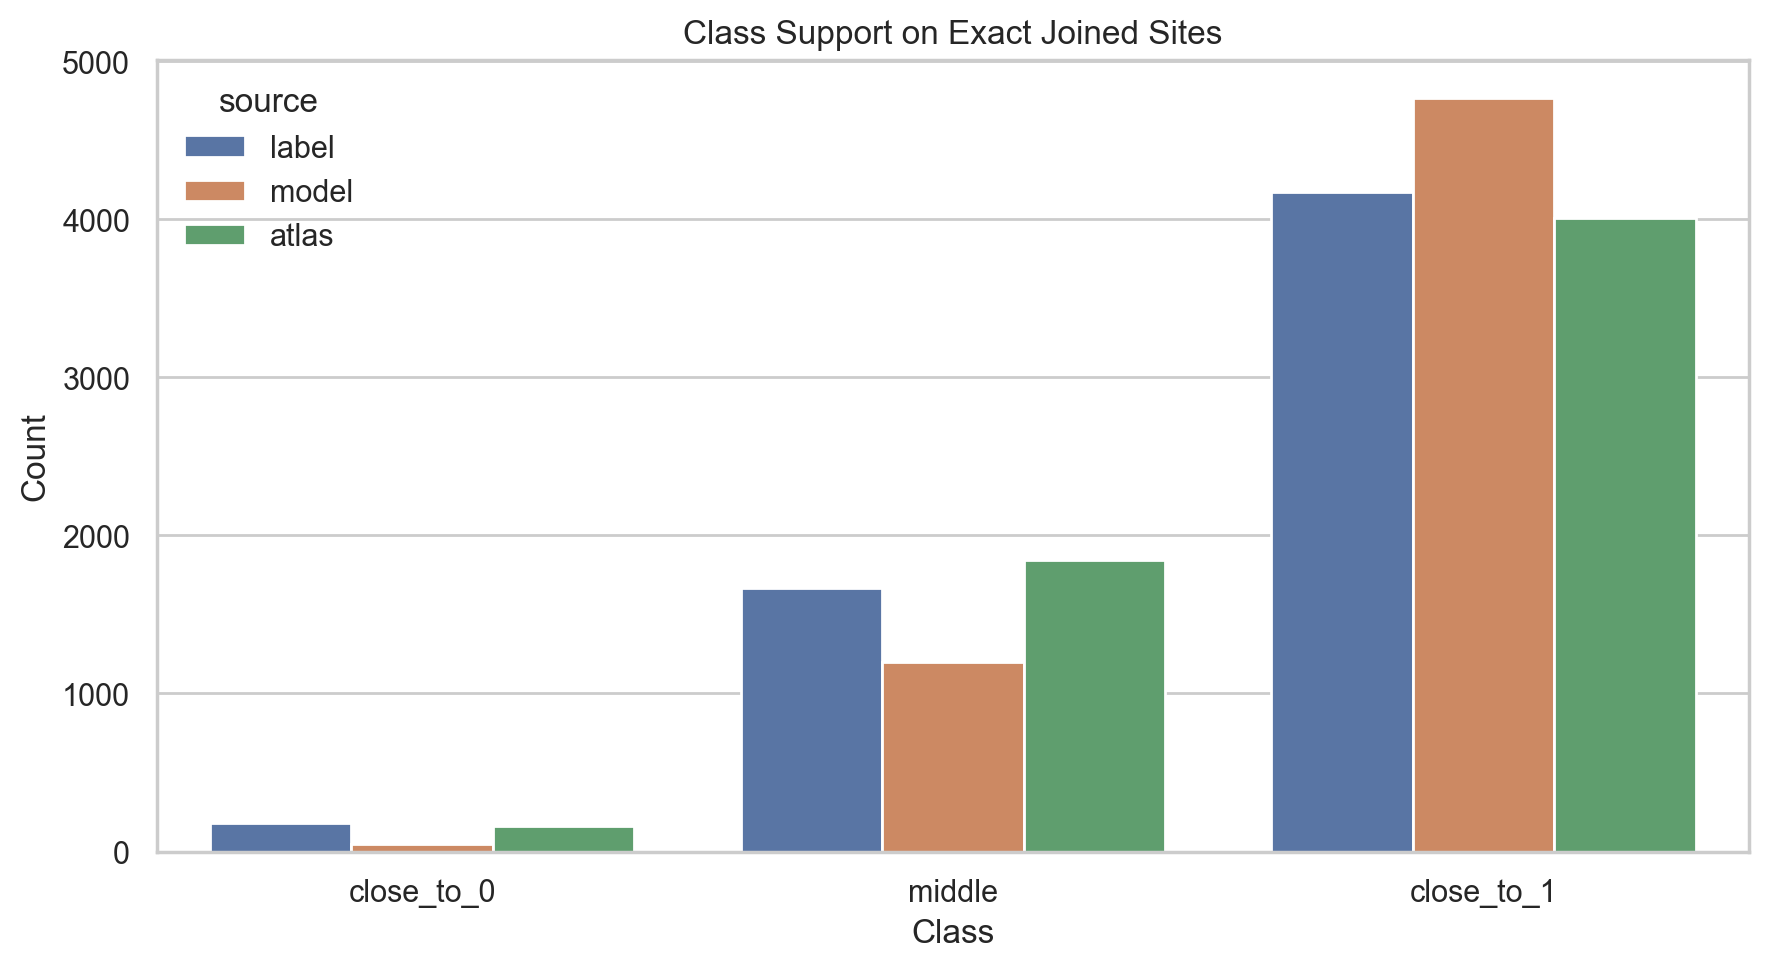

### confusion_heatmaps.png

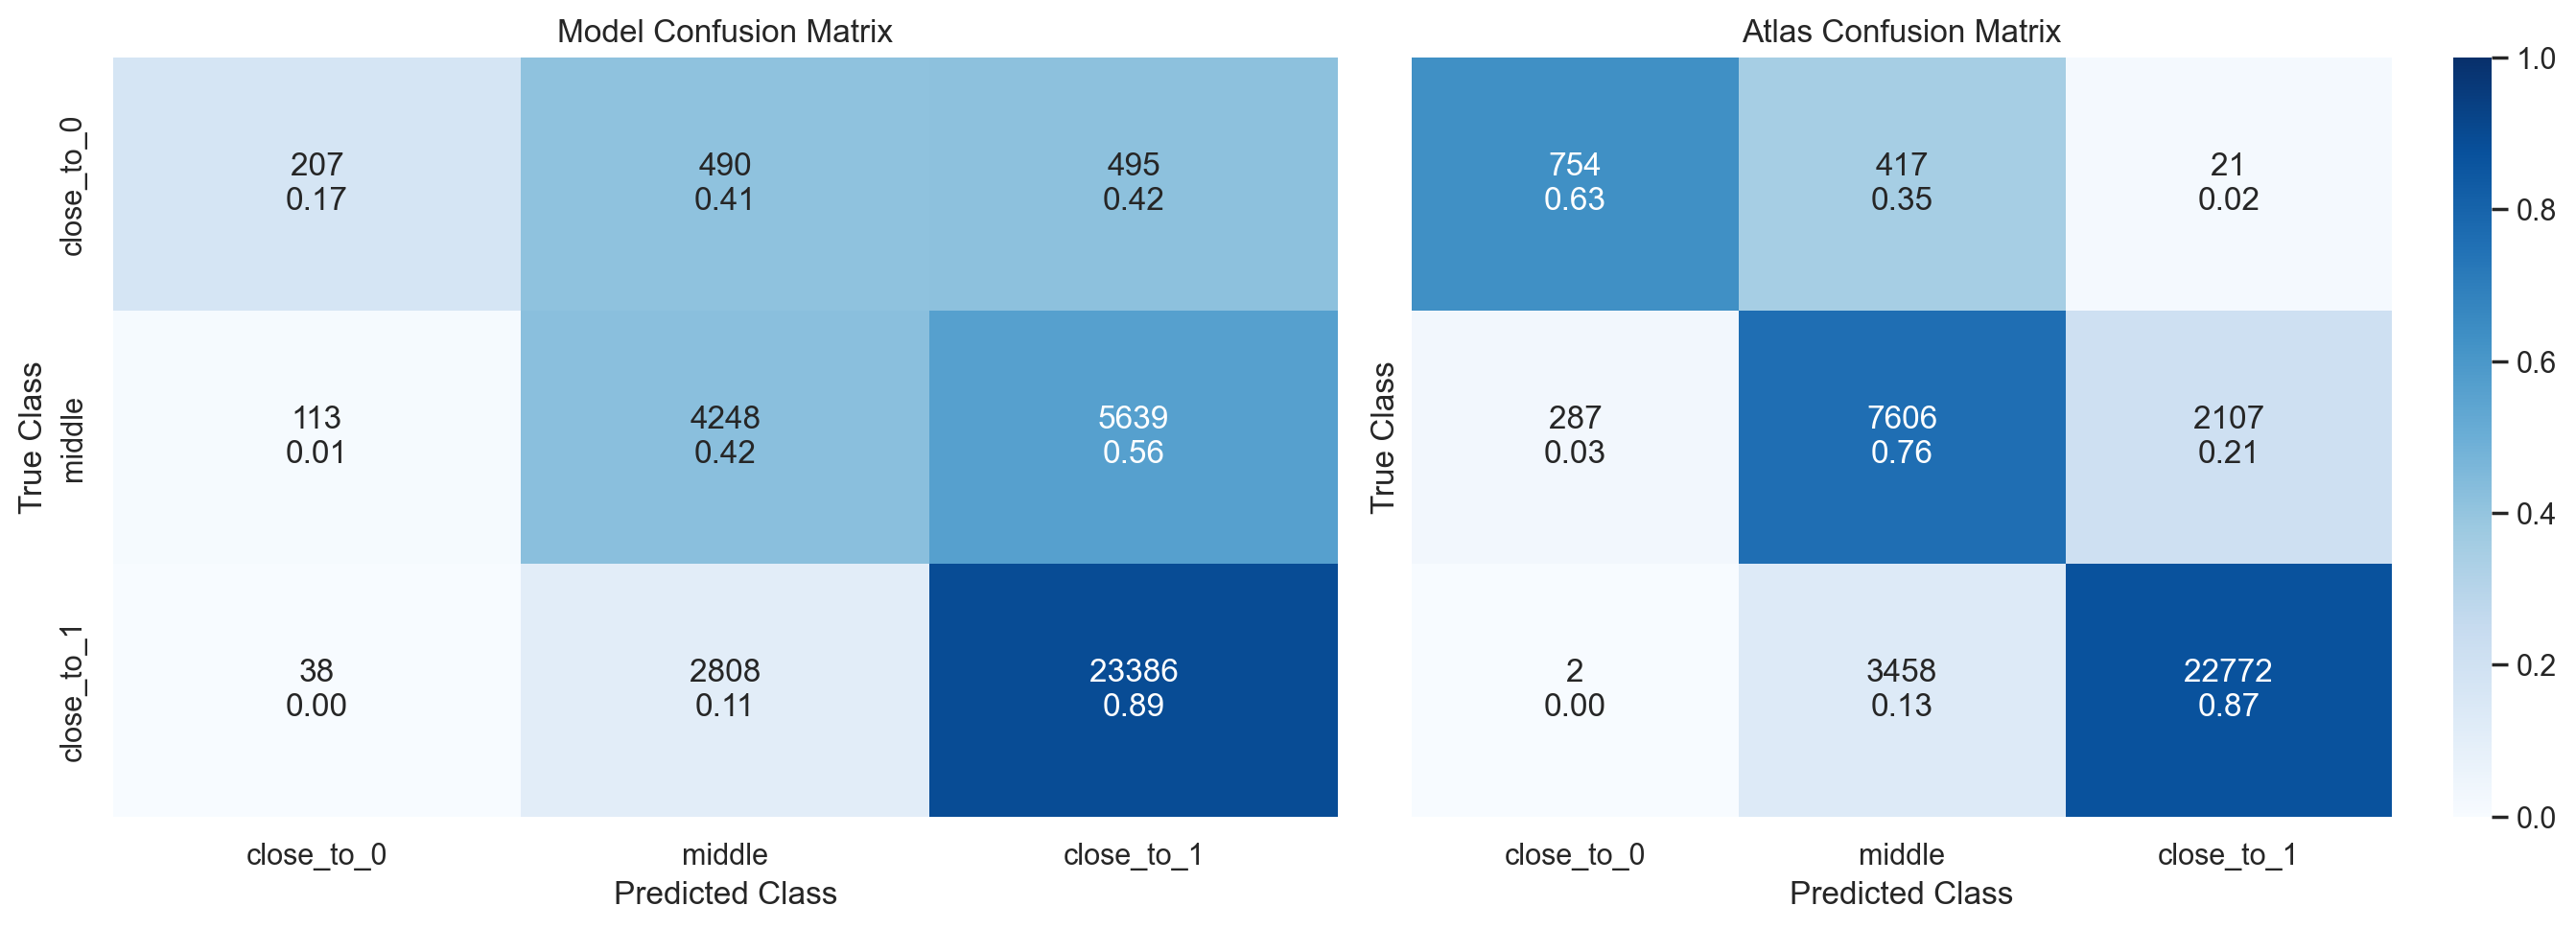

### overall_metrics_comparison.png

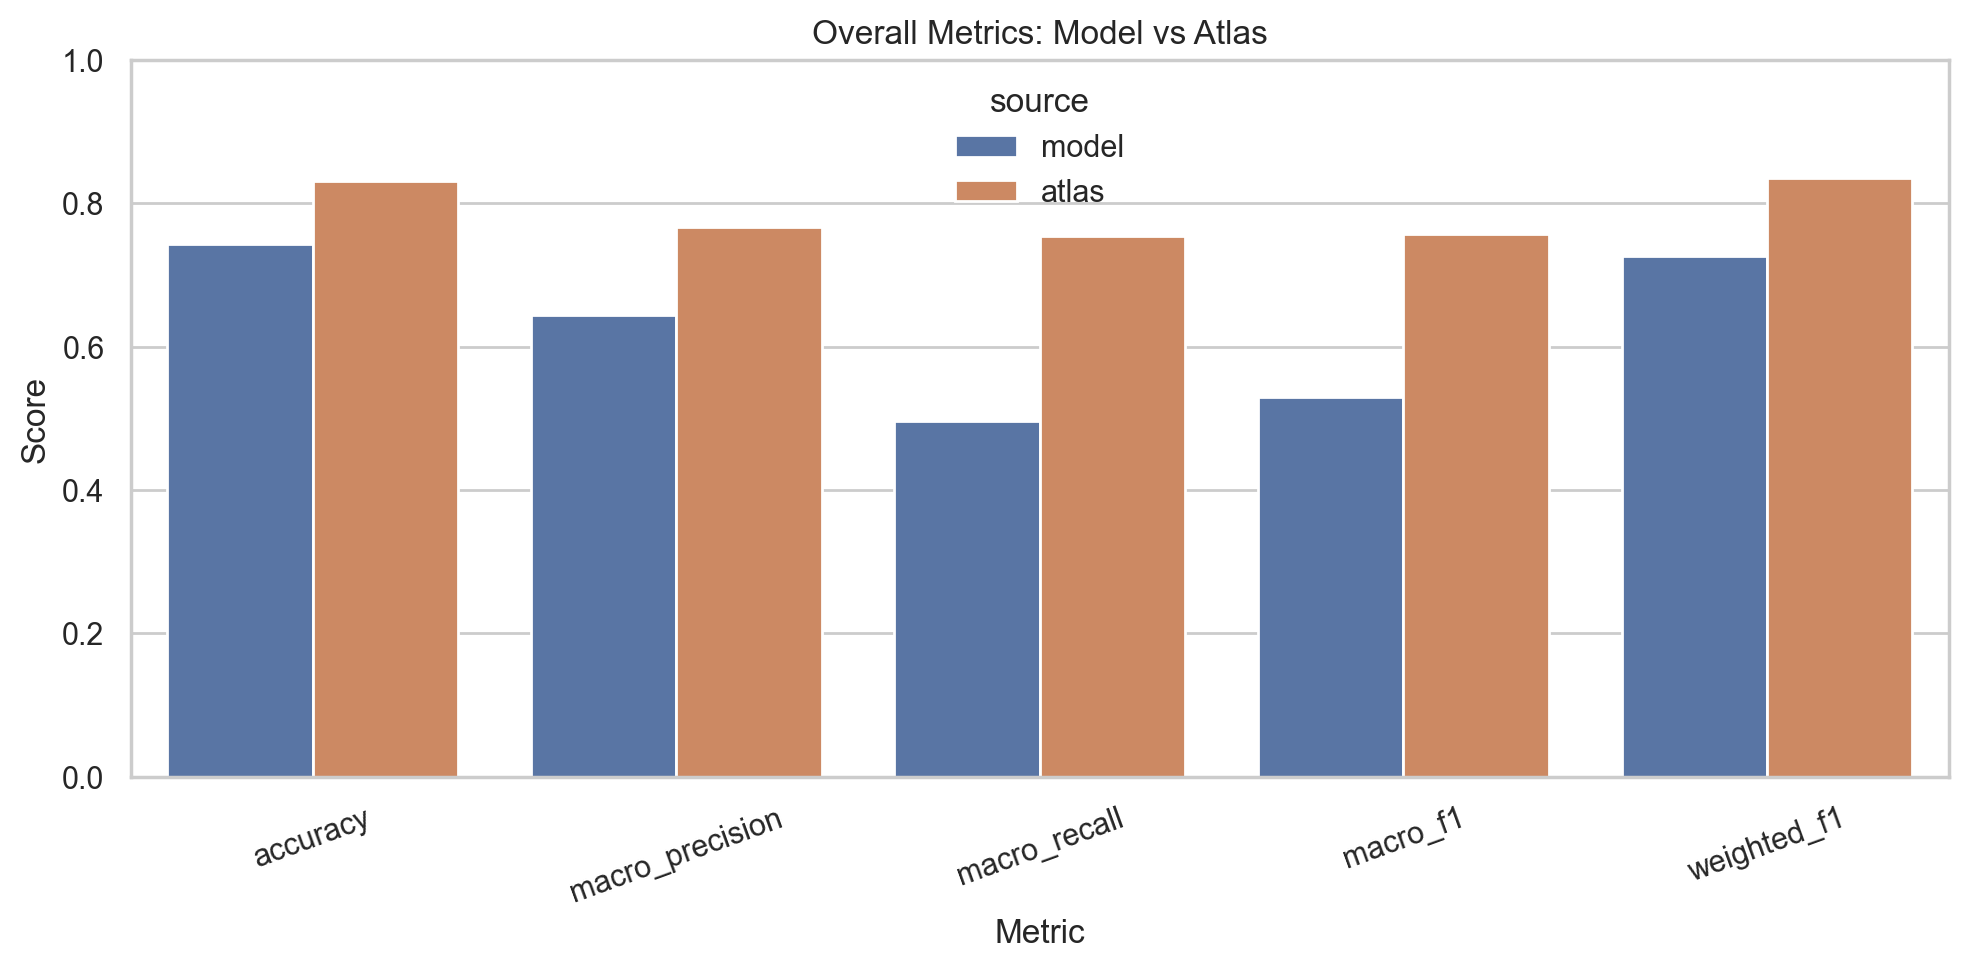

### pair_support.png

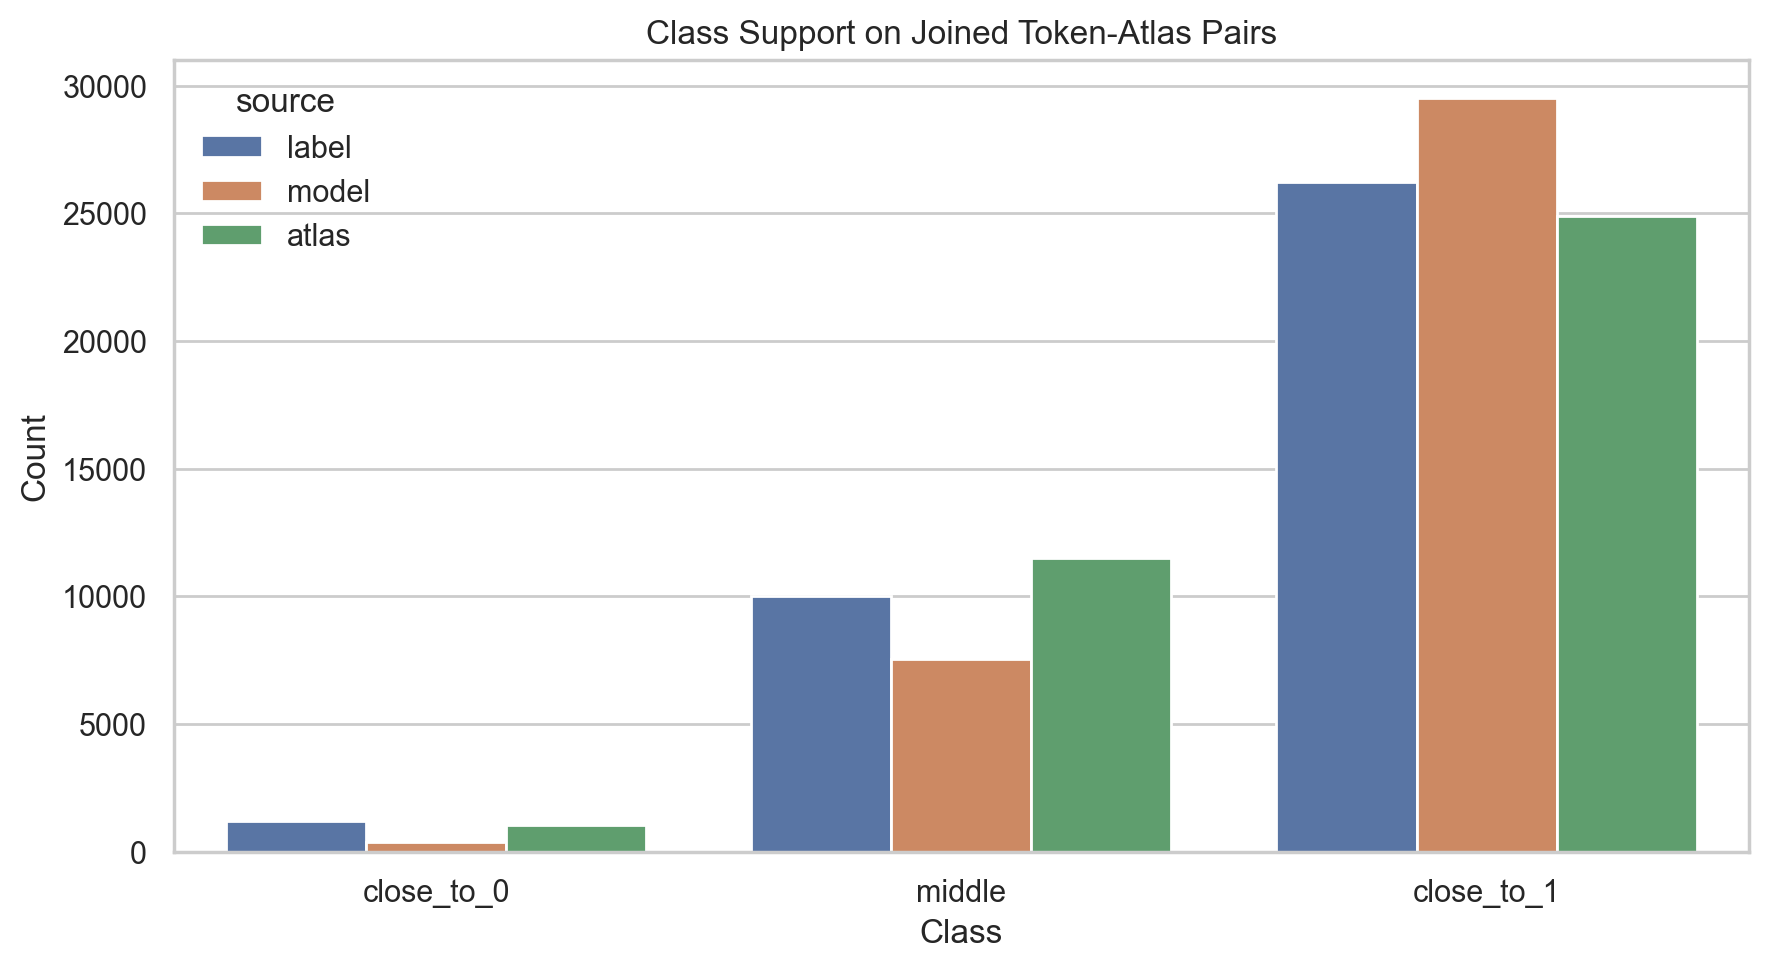

### per_class_metrics_comparison.png

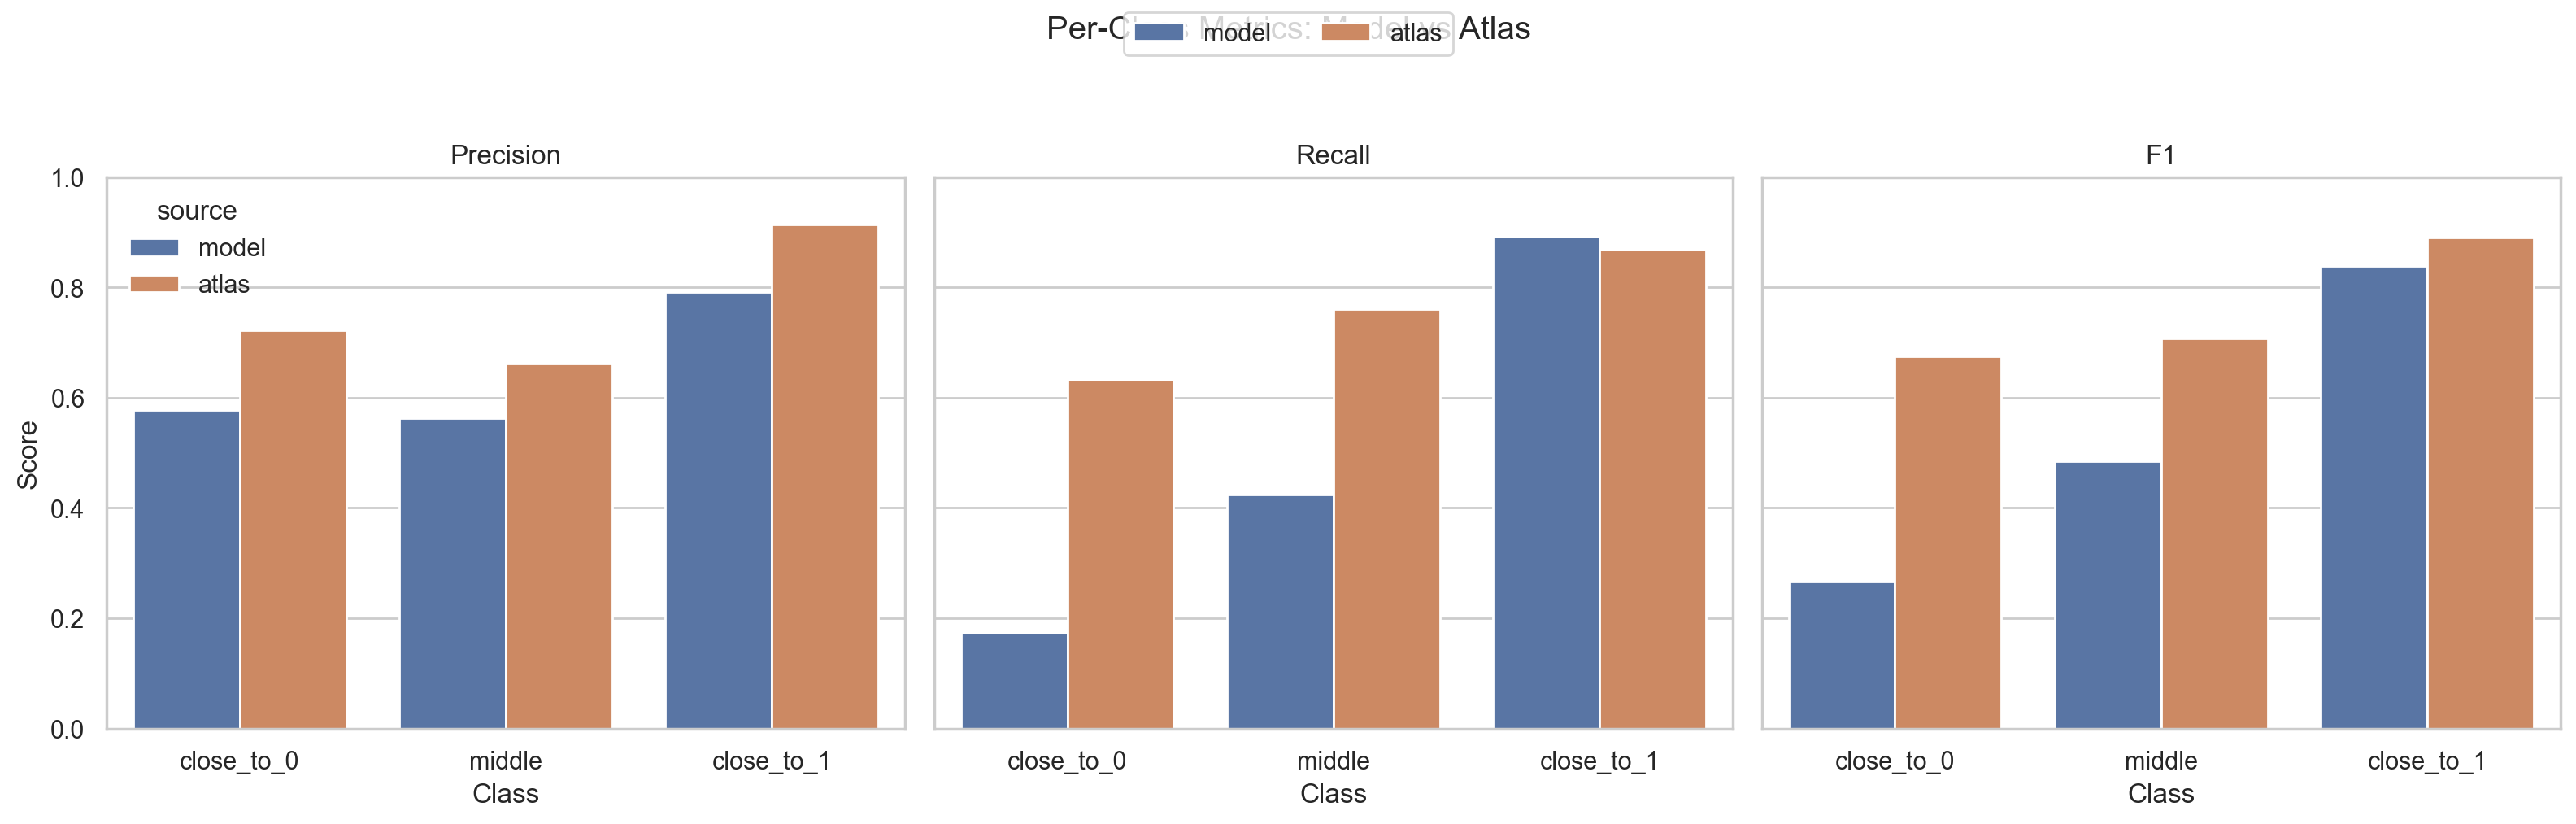

In [6]:
figure_paths = sorted(FIGURES_DIR.glob('*.png'))
if not figure_paths:
    raise FileNotFoundError(f'No figures were found in {FIGURES_DIR}')

for figure_path in figure_paths:
    display(Markdown(f'### {figure_path.name}'))
    display(Image(filename=str(figure_path)))

In [7]:
print('Saved outputs:')
for path in [
    comparison['overall_metrics_path'],
    comparison['per_class_metrics_path'],
    comparison['confusion_path'],
    comparison['delta_metrics_path'],
    comparison['joined_sites_path'],
]:
    print(path)

Saved outputs:
/sci/nosnap/michall/roeizucker/jupyter_notebooks/Tom_Hope_Project/refactored_code/notebooks/results/token_cls_bladder_epithelial_atlas_compare/overall_metrics.csv
/sci/nosnap/michall/roeizucker/jupyter_notebooks/Tom_Hope_Project/refactored_code/notebooks/results/token_cls_bladder_epithelial_atlas_compare/per_class_metrics.csv
/sci/nosnap/michall/roeizucker/jupyter_notebooks/Tom_Hope_Project/refactored_code/notebooks/results/token_cls_bladder_epithelial_atlas_compare/confusion_counts.csv
/sci/nosnap/michall/roeizucker/jupyter_notebooks/Tom_Hope_Project/refactored_code/notebooks/results/token_cls_bladder_epithelial_atlas_compare/delta_metrics.csv
/sci/nosnap/michall/roeizucker/jupyter_notebooks/Tom_Hope_Project/refactored_code/notebooks/results/token_cls_bladder_epithelial_atlas_compare/joined_sites.csv.gz
